In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Data loading and reading

🛳️ Titanic Dataset  Column Explanation

The Titanic dataset is a classic **binary classification** dataset:  
Goal = Predict whether a passenger survived (`Survived = 1`) or (`not Survived = 0`).  

---

 📊 Columns Description

1. **PassengerId** : Unique identifier for each passenger.  
2. **Survived** (Target variable)  
   - `0 = Did not survive`  
   - `1 = Survived`  

3. **Pclass** (Passenger Class)  : Ticket class, proxy for socio-economic status:  
     - `1 = 1st class (wealthy)`  
     - `2 = 2nd class`  
     - `3 = 3rd class (lower class)`  

4. **Name**  : Passenger name .  

5. **Sex** : Gender of passenger (`male` / `female`).  

6. **Age** : Age in years.  

7. **SibSp** (Siblings/Spouses aboard) : Number of siblings and spouses traveling with the passenger.  

8. **Parch** (Parents/Children aboard) : Number of parents and children traveling with the passenger.  

9. **Ticket** : Ticket number.  

10. **Fare** : Amount paid for the ticket.  

11. **Cabin** : Cabin number.  

12. **Embarked** : Port of embarkation:  
      - `C = Cherbourg`  
      - `Q = Queenstown`  
      - `S = Southampton`  

---



In [2]:
df_titanic = pd.read_csv(r'C:\Users\j\Desktop\BrainerX\notebooks\datasets\titanic_dataset\Titanic-Dataset.csv')

In [3]:
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df_titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df_titanic.shape

(891, 12)

In [7]:
df_titanic.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


# Data cleaning and Pre-processing

## Check Types

In [8]:
df_titanic.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

## Duplicates

In [9]:
df_titanic.duplicated().sum()

0

In [10]:
df_titanic.drop_duplicates()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


##Missing Values

In [11]:
missing_values = df_titanic.isnull().sum()
missing_values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
missing_values_percent = df_titanic.isnull().mean() * 100
missing_values_percent

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

<Axes: >

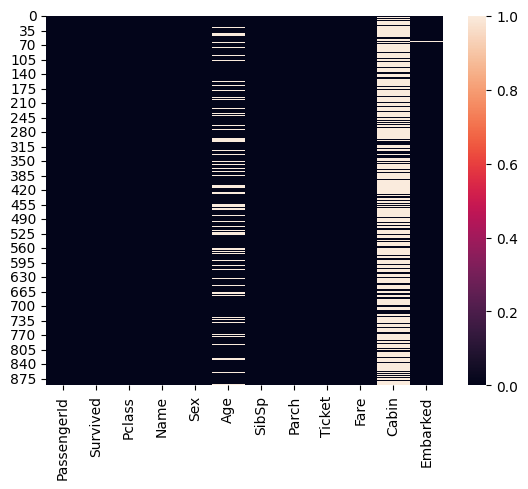

In [13]:
sns.heatmap(df_titanic.isnull())

| Variable Type                             | Distribution / Situation      | Best Imputation Method       |
| ----------------------------------------- | ----------------------------- | ---------------------------- |
| **Numeric (continuous)**                  | Normal / symmetric            | **Mean**                     |
|                                           | Skewed / with outliers        | **Median**                   |
| **Categorical**                           | One category clearly dominant | **Mode**                     |
|                                           | Many missing values (>50%)    | **Drop** or create "Unknown" |
| **High-cardinality (like Ticket, Cabin)** | Too many categories + missing | **Drop / Extract features**  |


**Age Variable**

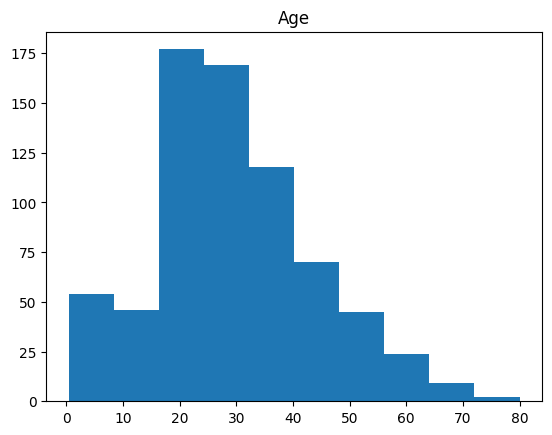

In [14]:
plt.hist(df_titanic['Age'])
plt.title("Age")
plt.show()

In [15]:
median_age = df_titanic['Age'].median()
median_age

28.0

In [16]:
df_titanic['Age'].fillna(median_age , inplace = True)

In [17]:
missing_percent = df_titanic.isnull().mean() * 100
print(missing_percent)

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


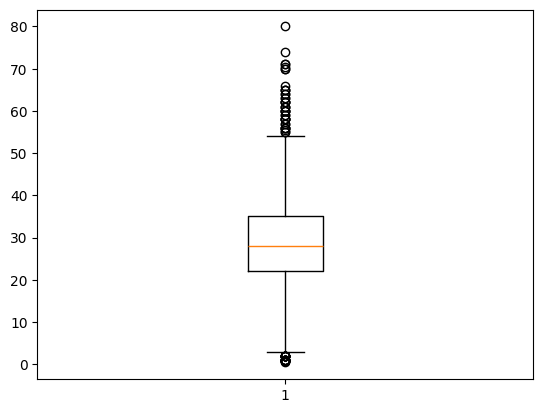

In [18]:
plt.boxplot(df_titanic['Age'])
plt.show()

In [19]:
missing_values_percent = df_titanic.isnull().mean() * 100
missing_values_percent

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

**Embarked Variable**

In [20]:
embaked_counts = df_titanic['Embarked'].unique()
embaked_counts

array(['S', 'C', 'Q', nan], dtype=object)

In [21]:
embaked_counts = df_titanic['Embarked'].value_counts()
embaked_counts

S    644
C    168
Q     77
Name: Embarked, dtype: int64

In [22]:
embarked_mode1 = df_titanic['Embarked'].mode()
embarked_mode1

0    S
Name: Embarked, dtype: object

In [23]:
embarked_mode = df_titanic['Embarked'].mode()[0]
embarked_mode

'S'

In [24]:
df_titanic['Embarked'].fillna(embarked_mode,inplace = True)

In [25]:
embaked_counts = df_titanic['Embarked'].value_counts()
embaked_counts

S    646
C    168
Q     77
Name: Embarked, dtype: int64

In [26]:
embaked_counts = df_titanic['Embarked'].unique()
embaked_counts

array(['S', 'C', 'Q'], dtype=object)

In [27]:
missing_values_percent = df_titanic.isnull().mean() * 100
missing_values_percent

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.000000
dtype: float64

**Cabin**

In [28]:
df_titanic.drop('Cabin' , inplace = True , axis = 1 )
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


<Axes: >

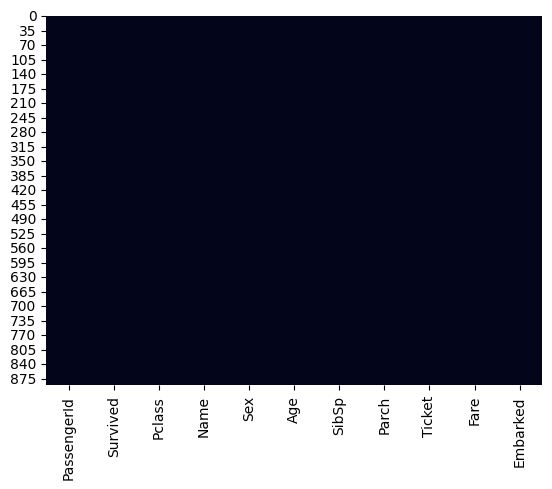

In [29]:
sns.heatmap(df_titanic.isnull(), cbar=False)

## Outliers

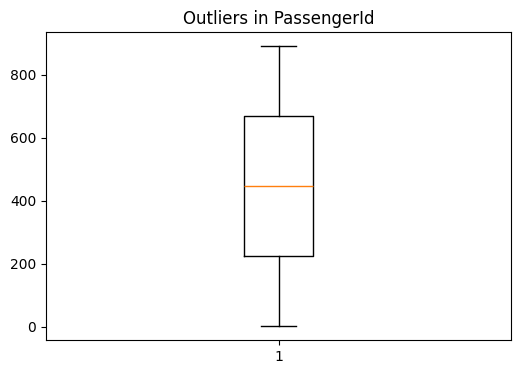

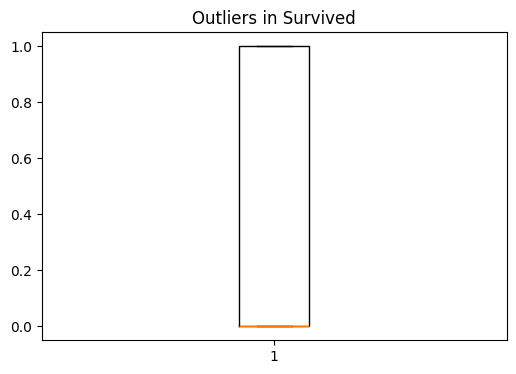

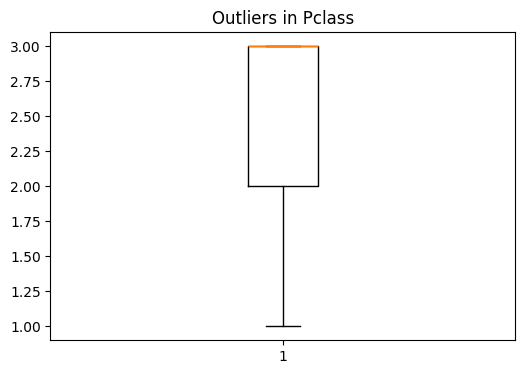

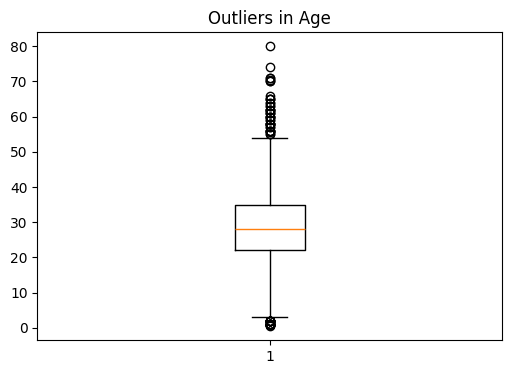

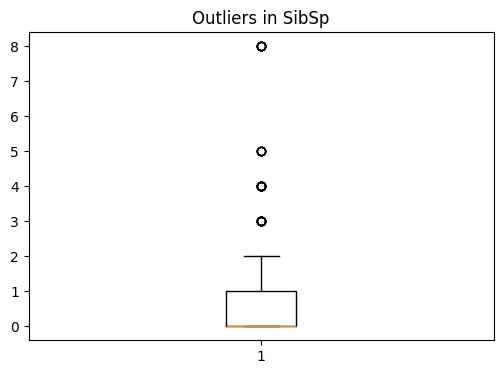

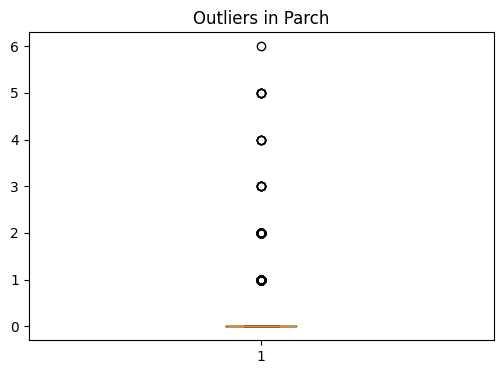

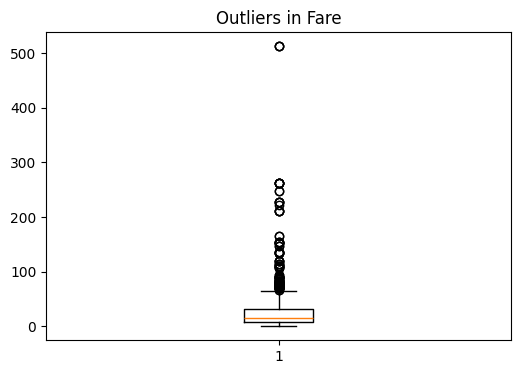

In [30]:
numeric_cols = df_titanic.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df_titanic[col].dropna())
    plt.title(f"Outliers in {col}")
    plt.show()


## Feature Engineering

In [31]:
df_titanic['FamilySize'] = df_titanic['SibSp'] + df_titanic['Parch'] + 1
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1


**Drop the useless columns**

In [32]:
df_titanic.drop(columns = ['PassengerId', 'Name', 'Ticket'] ,inplace=True)

In [33]:
df_titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,0,3,male,22.0,1,0,7.2500,S,2
1,1,1,female,38.0,1,0,71.2833,C,2
2,1,3,female,26.0,0,0,7.9250,S,1
3,1,1,female,35.0,1,0,53.1000,S,2
4,0,3,male,35.0,0,0,8.0500,S,1


## Enconding

There are two types of categorical data:
- **Ordinal Data** (has a meaningful order, e.g. Low, Medium, High)
- **Nominal Data** (no inherent order, e.g. Red, Blue, Green)

| Encoding Type        | How It Works                                                                           | Advantages 👍                                                              | Limitations 👎                                                                                                                               |
|----------------------|----------------------------------------------------------------------------------------|----------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------|
| **Label Encoding**    | Assigns an integer to each category (e.g. Red=0, Blue=1, Green=2)                      | - Simple, fast<br>- Low memory usage                                       | - Creates **false order** if used on nominal variables<br>- Misleads models into thinking `2 > 1 > 0`                                       |
| **One-Hot Encoding**  | Creates a binary column for each category (e.g. Red → [1,0,0], Blue → [0,1,0])         | - No false ranking<br>- Widely supported by most ML models                 | - Can increase dimensionality (problematic with high-cardinality features)<br>- May lead to sparsity                                        |
| **Ordinal Encoding**  | Maps categories to ordered integers *you define* (e.g. Low=1, Medium=2, High=3)       | - Preserves real order<br>- More informative for ordinal features          | - Assumes equal intervals between values<br>- Not suitable for nominal data                                                                 |

#### One Hot Encoding

In [34]:
df_encoded = pd.get_dummies(df_titanic, columns=['Sex', 'Embarked'], prefix=['Sex', 'Embarked'])
df_encoded.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,2,0,1,0,0,1
1,1,1,38.0,1,0,71.2833,2,1,0,1,0,0
2,1,3,26.0,0,0,7.9250,1,1,0,0,0,1
3,1,1,35.0,1,0,53.1000,2,1,0,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1,0,0,1


### 📝 Rest Encoding Examples

---

#### Label Encoding
```python
from sklearn.preprocessing import LabelEncoder

# Example: Pclass (Ordinal)
pclass = ["1", "2", "3", "1", "2"]

le = LabelEncoder()
pclass_encoded = le.fit_transform(pclass)
print(pclass_encoded)


####  Ordinal Encoding
```python
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

cabin_size = np.array([['Small'], ['Medium'], ['Large'], ['Small']])

# Define the order explicitly
ord_enc = OrdinalEncoder(categories=[['Small', 'Medium', 'Large']])

cabin_encoded = ord_enc.fit_transform(cabin_size)

print(cabin_encoded)


## EDA "Exploratory Data Analysis"

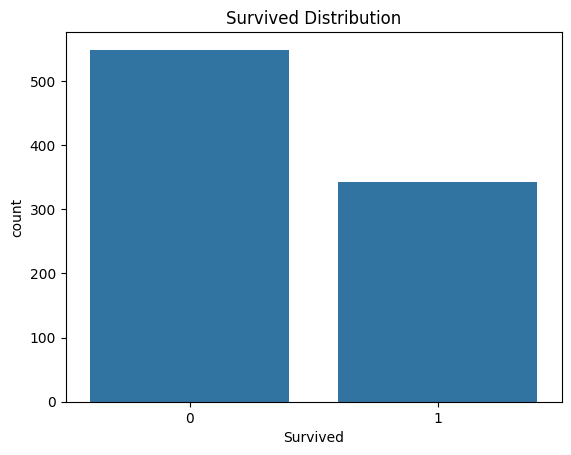

In [35]:
sns.countplot(x="Survived",data = df_titanic)
plt.title("Survived Distribution")
plt.show()

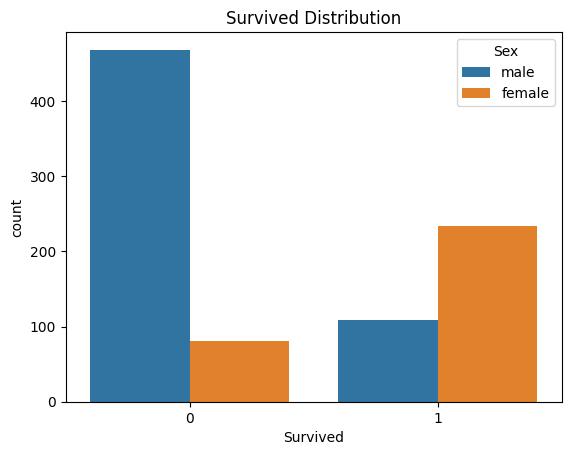

In [36]:
sns.countplot(x="Survived",data = df_titanic , hue='Sex')
plt.title("Survived Distribution")
plt.show()

<Axes: xlabel='Pclass', ylabel='count'>

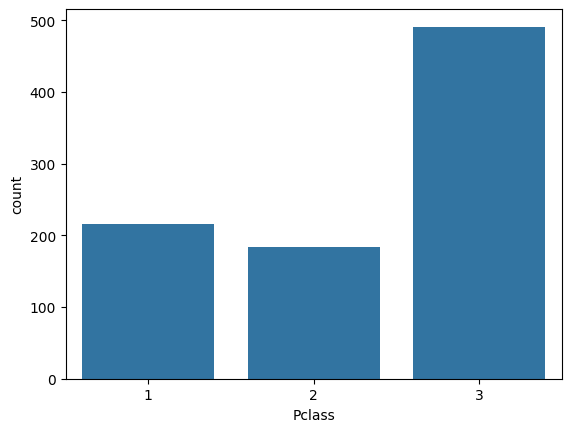

In [37]:
sns.countplot(x="Pclass", data=df_titanic)

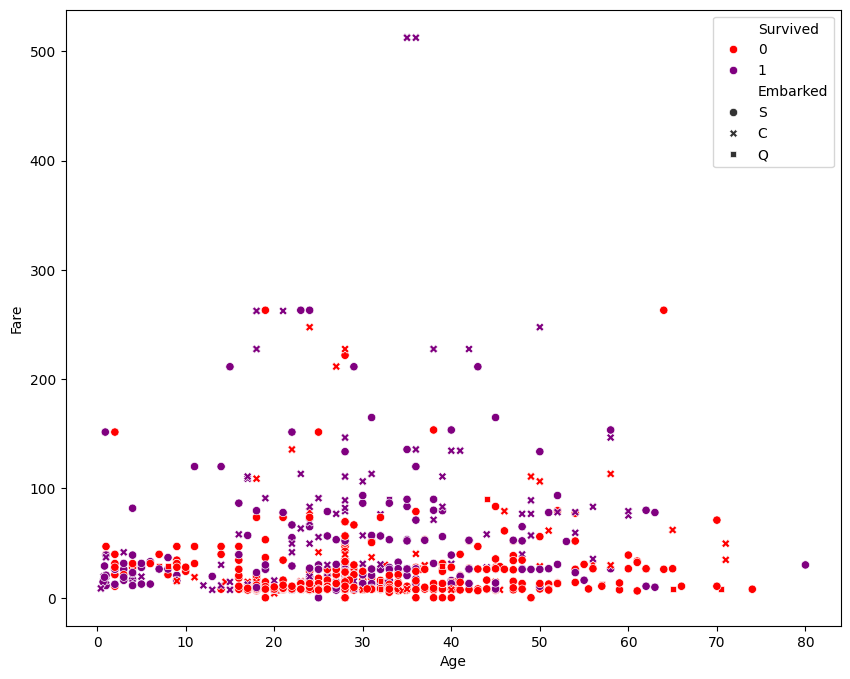

In [38]:
plt.figure(figsize=(10,8))
sns.scatterplot(
    x='Age',
    y='Fare',
    data = df_titanic,
    hue = 'Survived',
    style = 'Embarked',
    palette= {0:'red' , 1:'purple' , },
    hue_order= [0,1]
)
plt.show()

C:\Users\j\AppData\Local\Temp\ipykernel_10200\754529934.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sex", y="Survived", data=df_titanic, palette="Set1")


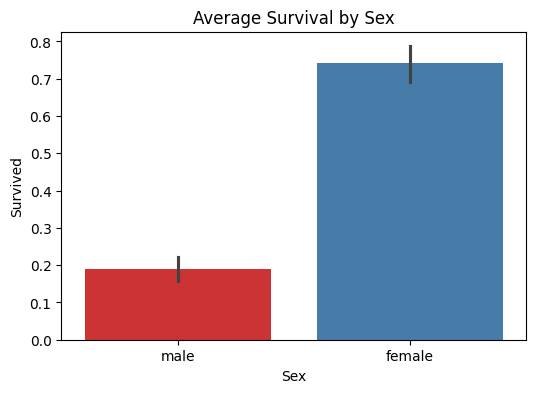

In [39]:
plt.figure(figsize=(6,4))
sns.barplot(x="Sex", y="Survived", data=df_titanic, palette="Set1")

plt.title("Average Survival by Sex")
plt.show()

<Axes: xlabel='Age', ylabel='Count'>

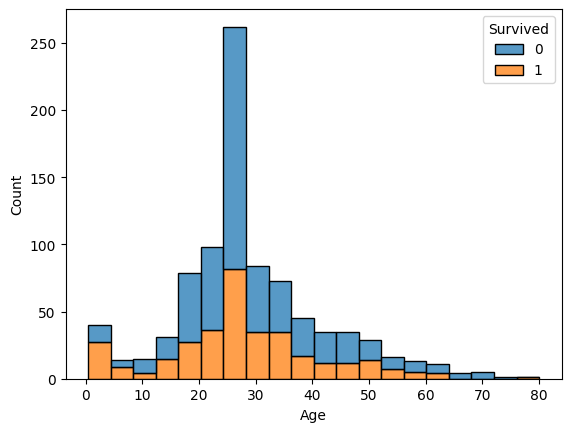

In [40]:
sns.histplot(data=df_titanic , x="Age", hue="Survived", bins=20, kde=False, multiple="stack")

C:\Users\j\AppData\Local\Temp\ipykernel_10200\2481163310.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Survived", y="Age", data=df_titanic, palette="coolwarm")


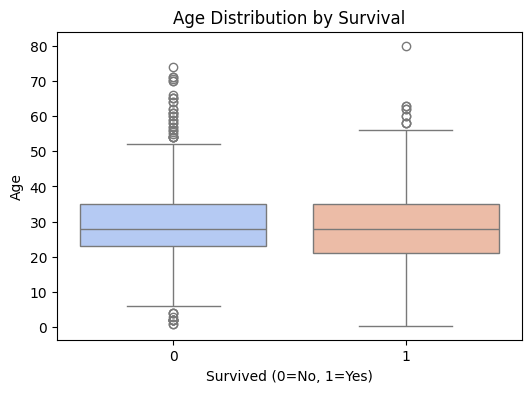

In [41]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Survived", y="Age", data=df_titanic, palette="coolwarm")
plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0=No, 1=Yes)")
plt.ylabel("Age")
plt.show()

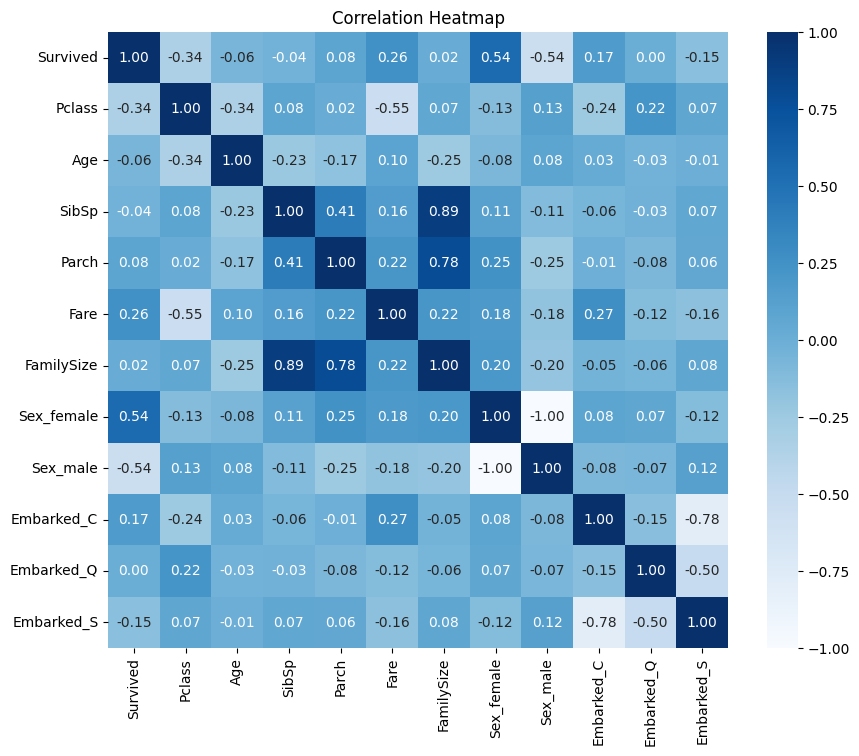

In [42]:
plt.figure(figsize=(10,8))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

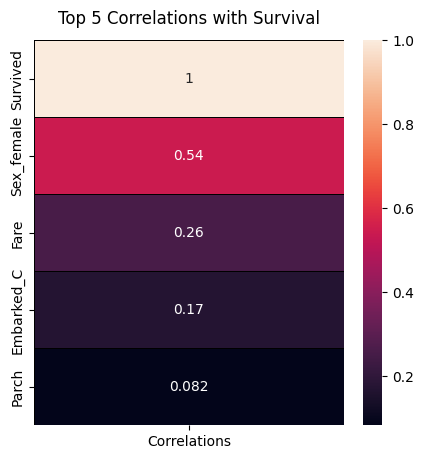

In [43]:
# Correlations
corr = df_encoded.corrwith(df_encoded['Survived']).sort_values(ascending=False)
corr = corr.to_frame(name='Correlations').head(5)

fig, ax = plt.subplots(figsize=(5,5))
sns.heatmap(corr, annot=True, linewidths=0.4, linecolor='black', ax=ax)
ax.set_title('Top 5 Correlations with Survival', fontsize=12, pad=12)
plt.show()

### Feature scaling

| Method                        | Formula                                                     | When to Use                                                                        |
| ----------------------------- | ----------------------------------------------------------- | ---------------------------------------------------------------------------------- |
| **Min-Max Scaling**           | $X' = \frac{X - X_{min}}{X_{max} - X_{min}}$ → range \[0,1] | When you want bounded values (e.g. neural networks, distance-based models)         |
| **Standardization (Z-score)** | $X' = \frac{X - \mu}{\sigma}$ → mean=0, std=1               | When data is normally distributed, or for algorithms like Logistic Regression, SVM |
| **Robust Scaling**            | $X' = \frac{X - Q2}{IQR} → Q2=median, IQR=Q3-Q1  $                                   | When data has **outliers**                                                         |

---

### 🔧 Coding Examples for Scaling

```python
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Example dataset
data = np.array([[10], [20], [30], [40], [50], [300], [500]])  # added outliers for Robust example

# 🚀 Min-Max Scaling
minmax_scaler = MinMaxScaler(feature_range=(0,1))
data_minmax = minmax_scaler.fit_transform(data)
print("Min-Max Scaling:\n", data_minmax)

# 📊 Standardization (Z-score)
std_scaler = StandardScaler()
data_standardized = std_scaler.fit_transform(data)
print("\nStandardization (Z-score):\n", data_standardized)

# 🛡️ Robust Scaling
robust_scaler = RobustScaler()
data_robust = robust_scaler.fit_transform(data)
print("\nRobust Scaling:\n", data_robust)


### Data Spliting

In [44]:
X = df_encoded.drop('Survived', axis=1)
y = df_encoded['Survived']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle = True , random_state=42)

You can scale on just numerical features

In [46]:
numeric_features = ['Age', 'Fare', 'FamillySize']
scaler = MinMaxScaler()
#X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
#X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [47]:
scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)

In [48]:
X_train_sc

array([[0.        , 0.34656949, 0.        , ..., 0.        , 0.        ,
        1.        ],
       [1.        , 0.30887158, 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.5       , 0.2963056 , 0.        , ..., 0.        , 0.        ,
        1.        ],
       ...,
       [1.        , 0.50992712, 0.25      , ..., 0.        , 0.        ,
        1.        ],
       [0.        , 0.17064589, 0.125     , ..., 0.        , 0.        ,
        1.        ],
       [0.        , 0.25860769, 0.        , ..., 0.        , 0.        ,
        1.        ]])

In [49]:
X_test_sc = scaler.transform(X_test)

In [50]:
X_test_sc

array([[1.        , 0.34656949, 0.125     , ..., 1.        , 0.        ,
        0.        ],
       [0.5       , 0.3842674 , 0.        , ..., 0.        , 0.        ,
        1.        ],
       [1.        , 0.24604172, 0.        , ..., 0.        , 0.        ,
        1.        ],
       ...,
       [1.        , 0.34656949, 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.5       , 0.2963056 , 0.        , ..., 0.        , 0.        ,
        1.        ],
       [1.        , 0.22090978, 0.125     , ..., 0.        , 0.        ,
        1.        ]])

## Model Building | Evaluation

### **KNN**

In [51]:
knn = KNeighborsClassifier(n_neighbors=5, metric="manhattan")
knn.fit(X_train_sc,y_train)

KNeighborsClassifier(metric='manhattan')

In [52]:
y_predict = knn.predict(X_test_sc)

In [53]:
cm = confusion_matrix(y_test,y_predict)
print(cm)

[[118  16]
 [ 25  64]]


<Axes: >

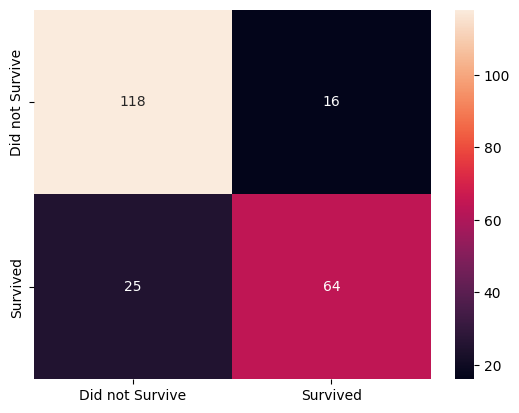

In [54]:
sns.heatmap(cm , fmt= 'd' , annot = True , xticklabels=['Did not Survive', 'Survived']
            , yticklabels=['Did not Survive', 'Survived'])

In [55]:
cr = classification_report(y_test,y_predict , digits=4)

In [56]:
print(cr)

              precision    recall  f1-score   support

           0     0.8252    0.8806    0.8520       134
           1     0.8000    0.7191    0.7574        89

    accuracy                         0.8161       223
   macro avg     0.8126    0.7998    0.8047       223
weighted avg     0.8151    0.8161    0.8142       223



**Predict** a new unseen passenger

In [57]:
def predict_survival(pclass, age, sibsp, parch, fare, sex, embarked):
    train_columns = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamillySize', 'Sex_female',
       'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']
    passenger = pd.DataFrame({
        'Pclass': [pclass],
        'Age': [age],
        'SibSp': [sibsp],
        'Parch': [parch],
        'Fare': [fare],
        'FamillySize': [sibsp + parch + 1],
        'Sex': [sex],
        'Embarked': [embarked]
    })

    # --- One-hot encoding ---
    passenger_encoded = pd.get_dummies(passenger, columns=['Sex','Embarked'], prefix=['Sex','Embarked'])
    print(passenger_encoded)

    for col in train_columns:
        if col not in passenger_encoded.columns:
            passenger_encoded[col] = 0
    passenger_encoded = passenger_encoded[train_columns]

    # --- Scaling ---
    passenger_scaled = scaler.transform(passenger_encoded)
    print(passenger_scaled)

    # --- Prediction & probabilities ---
    prediction = knn.predict(passenger_scaled)[0]
    proba = knn.predict_proba(passenger_scaled)[0]

    # --- Output ---
    result = "Survived" if prediction == 1 else "Did not survive"
    print(result, f"(Survival Probability: {proba[1]:.2f})")

In [61]:
predict_survival(pclass=3, age=25, sibsp=0, parch=0, fare= 17.25, sex='male', embarked='S')

   Pclass  Age  SibSp  Parch   Fare  FamillySize  Sex_male  Embarked_S
0       3   25      0      0  17.25            1         1           1


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- FamillySize
Feature names seen at fit time, yet now missing:
- FamilySize


### **Decision Tree**

In [ ]:
dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42 ,
    max_depth = 3
)

In [ ]:
dt.fit(X_train , y_train)
y_predict_dt = dt.predict(X_test)

In [ ]:
cm_dt = confusion_matrix(y_test, y_predict_dt)
print(cm_dt)

[[118  16]
 [ 27  62]]


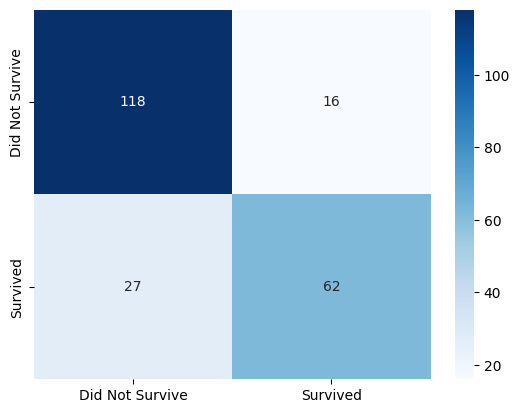

In [ ]:
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues", xticklabels=['Did Not Survive','Survived'], yticklabels=['Did Not Survive','Survived'])
plt.show()

In [ ]:
print(classification_report(y_test, y_predict_dt, digits = 4 , target_names=['Did Not Survive', 'Survived']))

                 precision    recall  f1-score   support

Did Not Survive     0.8138    0.8806    0.8459       134
       Survived     0.7949    0.6966    0.7425        89

       accuracy                         0.8072       223
      macro avg     0.8043    0.7886    0.7942       223
   weighted avg     0.8062    0.8072    0.8046       223



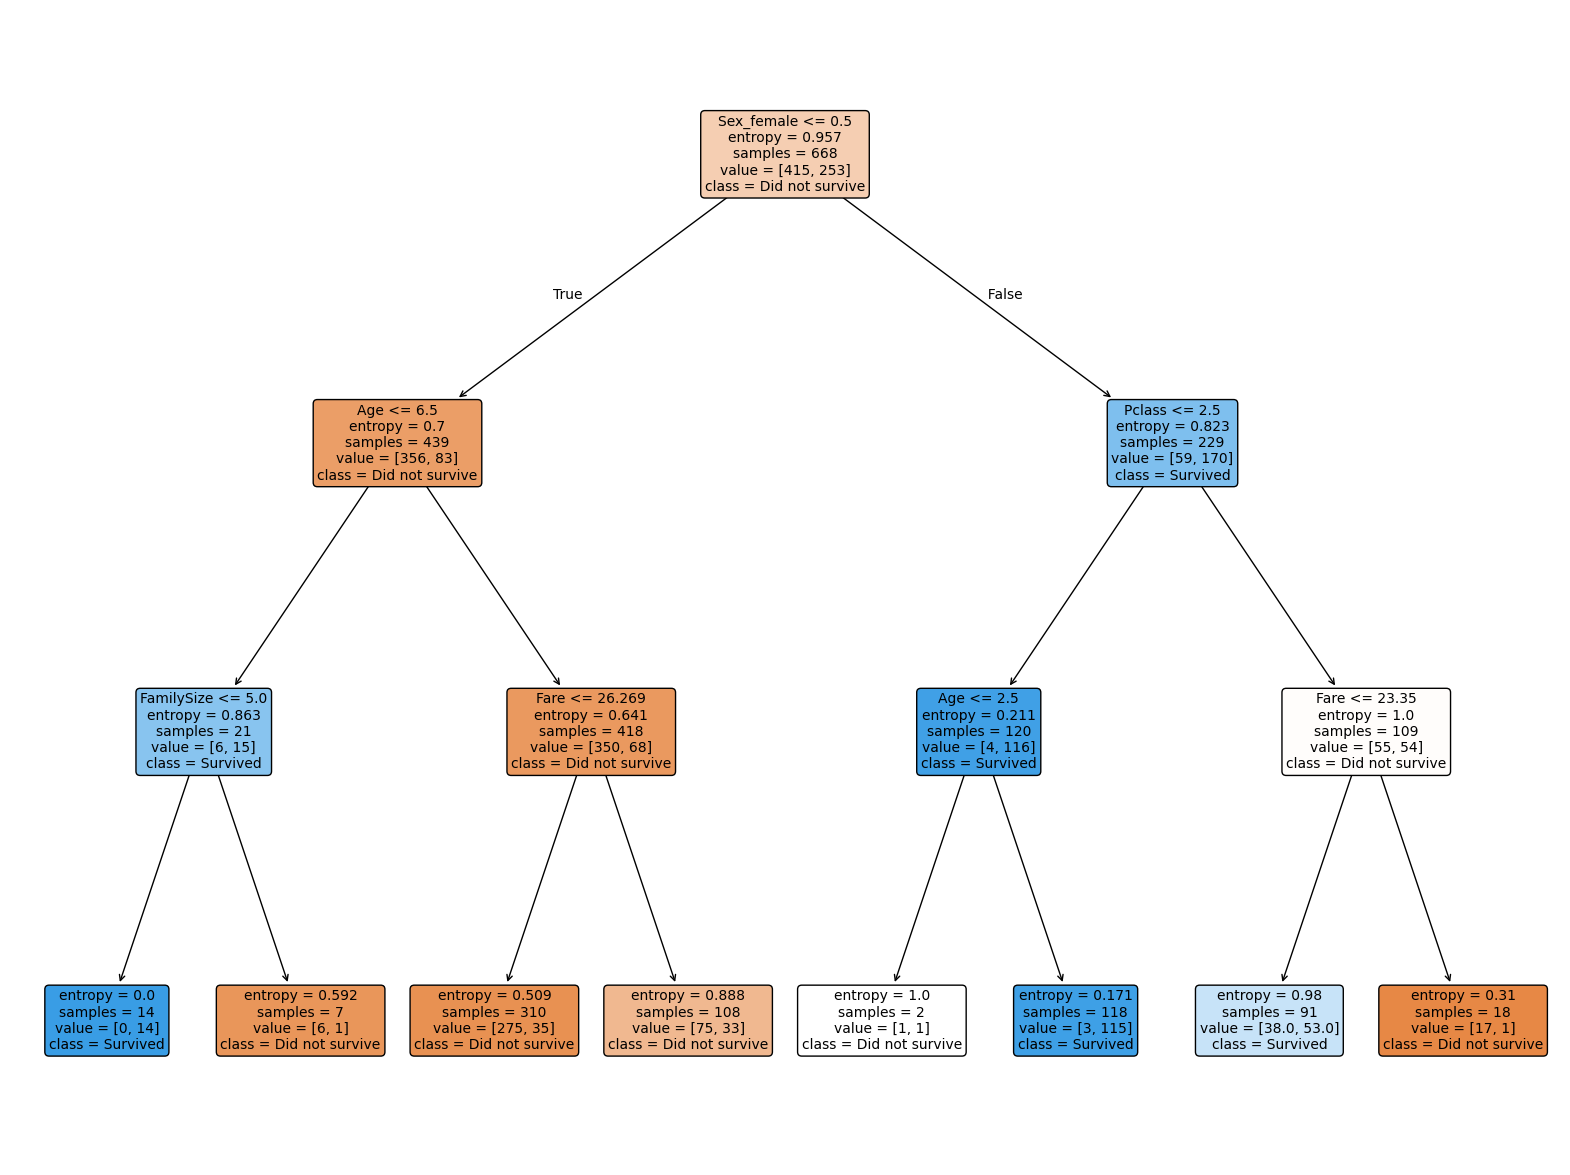

In [ ]:
plt.figure(figsize=(20,15))
plot_tree(dt,
          feature_names=X.columns,
          class_names=["Did not survive", "Survived"],
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()

### **Random Forest**

In [ ]:
rf = RandomForestClassifier(
    n_estimators=50 ,
    max_depth = 4,
    min_samples_leaf=12,
    random_state=42,
)

In [ ]:
rf.fit(X_train , y_train)
y_predict_rf = rf.predict(X_test)

In [ ]:
print(classification_report(y_test, y_predict_rf, target_names=['Did Not Survive', 'Survived'] , digits = 4))

                 precision    recall  f1-score   support

Did Not Survive     0.8207    0.8881    0.8530       134
       Survived     0.8077    0.7079    0.7545        89

       accuracy                         0.8161       223
      macro avg     0.8142    0.7980    0.8038       223
   weighted avg     0.8155    0.8161    0.8137       223



### **XGBoost Classifier**

In [ ]:
xgb = XGBClassifier(
    n_estimators=100,   # number of trees
    max_depth=3,        # depth of each tree
    learning_rate=0.1,  # step size shrinkage
    random_state=42,
)

In [ ]:
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_xgb, target_names=['Did Not Survive', 'Survived'] , digits = 4))

                 precision    recall  f1-score   support

Did Not Survive     0.8188    0.9104    0.8622       134
       Survived     0.8378    0.6966    0.7607        89

       accuracy                         0.8251       223
      macro avg     0.8283    0.8035    0.8115       223
   weighted avg     0.8264    0.8251    0.8217       223

